In [1]:
!pip install nibabel

In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import MeanIoU
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

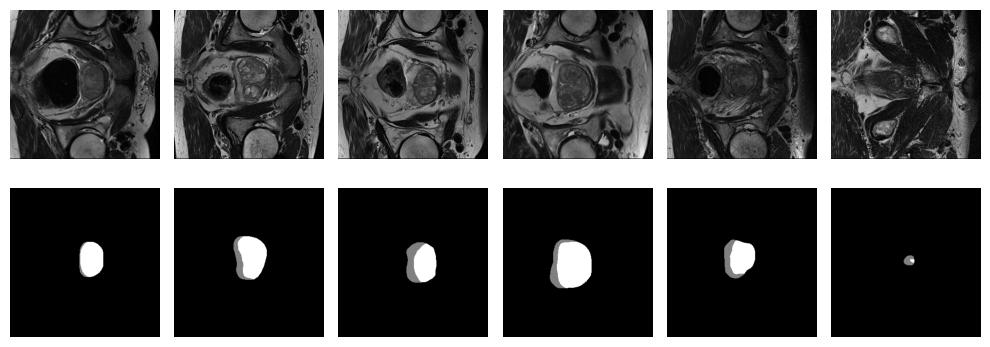

In [3]:
base_path = "DATASET"  
images_dir = os.path.join(base_path, "imagesTr")
labels_dir = os.path.join(base_path, "labelsTr")

image_files = sorted(os.listdir(images_dir))[:6]
label_files = sorted(os.listdir(labels_dir))[:6]

image_slices = []
label_slices = []

for i in range(6):
    image_path = os.path.join(images_dir, image_files[i])
    label_path = os.path.join(labels_dir, label_files[i])
    img = nib.load(image_path).get_fdata()
    lbl = nib.load(label_path).get_fdata()

    if img.ndim == 3 and img.shape[-1] == 2:
        img_slice = img[:, :, 0]  
    elif img.ndim == 3:
        slice_index = img.shape[2] // 2
        img_slice = img[:, :, slice_index]
    elif img.ndim == 4:
        slice_index = img.shape[2] // 2
        img_slice = img[:, :, slice_index, 0]

    if lbl.ndim == 3:
        slice_index_lbl = lbl.shape[2] // 2
        lbl_slice = lbl[:, :, slice_index_lbl]

    image_slices.append(img_slice)
    label_slices.append(lbl_slice)

plt.figure(figsize=(10,4))

for i in range(6):
    plt.subplot(2, 6, i + 1)
    plt.imshow(image_slices[i], cmap='gray')
    plt.axis('off')

    plt.subplot(2, 6, i + 7)
    plt.imshow(label_slices[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

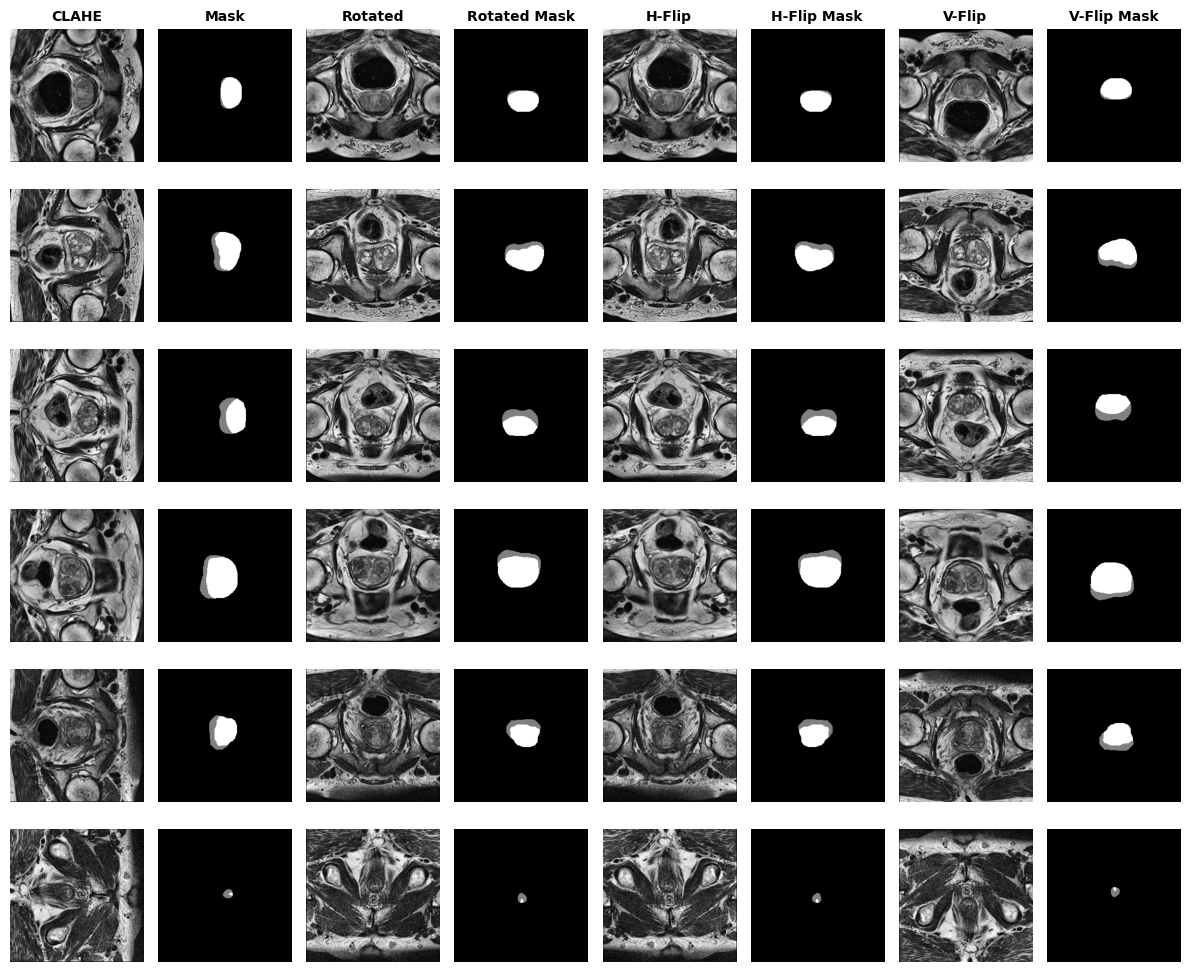

In [4]:
image_files = sorted(os.listdir(images_dir))[:6]
label_files = sorted(os.listdir(labels_dir))[:6]

def preprocess_image_and_mask(image, mask, resize_shape=(256, 256)):
    image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    image = cv2.resize(image, resize_shape, interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, resize_shape, interpolation=cv2.INTER_NEAREST)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_clahe = clahe.apply(image)
    image_rot = cv2.rotate(image_clahe, cv2.ROTATE_90_CLOCKWISE)
    mask_rot = cv2.rotate(mask, cv2.ROTATE_90_CLOCKWISE)
    image_hflip = cv2.flip(image_rot, 1)
    mask_hflip = cv2.flip(mask_rot, 1)
    image_vflip = cv2.flip(image_rot, 0)
    mask_vflip = cv2.flip(mask_rot, 0)
    return image_clahe, mask, image_rot, mask_rot, image_hflip, mask_hflip, image_vflip, mask_vflip
    
fig, axes = plt.subplots(6, 8, figsize=(12, 10))
titles = ["CLAHE", "Mask", "Rotated", "Rotated Mask", "H-Flip", "H-Flip Mask", "V-Flip", "V-Flip Mask"]

for i in range(6):
    img = nib.load(os.path.join(images_dir, image_files[i])).get_fdata()
    lbl = nib.load(os.path.join(labels_dir, label_files[i])).get_fdata()
    
    if img.ndim == 3 and img.shape[-1] == 2:
        img_slice = img[:, :, 0]
    elif img.ndim == 3:
        img_slice = img[:, :, img.shape[2] // 2]
    elif img.ndim == 4:
        img_slice = img[:, :, img.shape[2] // 2, 0]

    if lbl.ndim == 3:
        lbl_slice = lbl[:, :, lbl.shape[2] // 2]

    clahe_img, resized_mask, rot_img, rot_mask, hflip_img, hflip_mask, vflip_img, vflip_mask = preprocess_image_and_mask(img_slice, lbl_slice)
    images_row = [clahe_img, resized_mask, rot_img, rot_mask, hflip_img, hflip_mask, vflip_img, vflip_mask]

    for j, im in enumerate(images_row):
        ax = axes[i, j]
        ax.imshow(im, cmap='gray')
        if i == 0:
            ax.set_title(titles[j], fontsize=10,fontweight="bold")
        ax.axis('off')

plt.tight_layout()
plt.show()

In [11]:
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

set_seed(42)
def load_nifti_image(filepath):
    img = nib.load(filepath).get_fdata()
    if img.ndim == 3:
        slice_idx = img.shape[2] // 2
        img_slice = img[:, :, slice_idx]
    elif img.ndim == 4:
        slice_idx = img.shape[2] // 2
        img_slice = img[:, :, slice_idx, 0]
    else:
        img_slice = img
    return img_slice

def preprocess_single_image(image, mask, resize_shape=(128, 128), apply_augmentation=False):
    image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    image = cv2.resize(image, resize_shape, interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, resize_shape, interpolation=cv2.INTER_NEAREST)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_clahe = clahe.apply(image)
    
    if apply_augmentation:
        image_rot = cv2.rotate(image_clahe, cv2.ROTATE_90_CLOCKWISE)
        mask_rot = cv2.rotate(mask, cv2.ROTATE_90_CLOCKWISE)
        image_hflip = cv2.flip(image_rot, 1)
        mask_hflip = cv2.flip(mask_rot, 1)
        image_vflip = cv2.flip(image_rot, 0)
        mask_vflip = cv2.flip(mask_rot, 0)
        
        return [(image_clahe, mask), (image_rot, mask_rot), 
                (image_hflip, mask_hflip), (image_vflip, mask_vflip)]
    else:
        return [(image_clahe, mask)]

def load_and_preprocess_data(images_dir, labels_dir, resize_shape=(128, 128), 
                            use_augmentation=True, test_size=0.2, val_size=0.15):
    image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(('.nii', '.nii.gz'))])
    label_files = sorted([f for f in os.listdir(labels_dir) if f.endswith(('.nii', '.nii.gz'))])
    image_files = image_files[:len(label_files)]
    
    print(f"Found {len(image_files)} image files")
    train_files, test_files = train_test_split(
        list(zip(image_files, label_files)), 
        test_size=test_size, 
        random_state=42
    )
    train_files, val_files = train_test_split(
        train_files, 
        test_size=val_size/(1-test_size), 
        random_state=42
    )
    def process_file_list(file_list, augment=False):
        images = []
        labels = []
        
        for img_file, lbl_file in tqdm(file_list, desc=f"Processing {'augmented' if augment else 'test'} data"):
            img_path = os.path.join(images_dir, img_file)
            lbl_path = os.path.join(labels_dir, lbl_file) 
            img_slice = load_nifti_image(img_path)
            lbl_slice = load_nifti_image(lbl_path)
            processed_pairs = preprocess_single_image(
                img_slice, lbl_slice, resize_shape, apply_augmentation=augment
            )
                
            for proc_img, proc_mask in processed_pairs:
                images.append(proc_img)
                labels.append(proc_mask)
                    
        return np.array(images), np.array(labels)
        
    X_train, y_train = process_file_list(train_files, augment=True)
    X_val, y_val = process_file_list(val_files, augment=False)
    X_test, y_test = process_file_list(test_files, augment=False)
    X_train = X_train[..., np.newaxis] / 255.0
    X_val = X_val[..., np.newaxis] / 255.0
    X_test = X_test[..., np.newaxis] / 255.0
    
    y_train = tf.keras.utils.to_categorical(y_train, num_classes=3)
    y_val = tf.keras.utils.to_categorical(y_val, num_classes=3)
    y_test = tf.keras.utils.to_categorical(y_test, num_classes=3)
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
    print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test
                
    
class WindowAttention(layers.Layer):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, dropout_rate=0.0):
        super(WindowAttention, self).__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        
        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.attn_drop = layers.Dropout(dropout_rate)
        self.proj = layers.Dense(dim)
        self.proj_drop = layers.Dropout(dropout_rate)
        
    def call(self, inputs, mask=None):
        x = inputs
        B = tf.shape(x)[0]
        N = tf.shape(x)[1]
        C = tf.shape(x)[2]
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, (B, N, 3, self.num_heads, C // self.num_heads))
        qkv = tf.transpose(qkv, (2, 0, 3, 1, 4))
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        
        if mask is not None:
            attn = attn + mask
            
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.attn_drop(attn)
        
        x = tf.matmul(attn, v)
        x = tf.transpose(x, (0, 2, 1, 3))
        x = tf.reshape(x, (B, N, C))
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class SwinTransformerBlock(layers.Layer):
    def __init__(self, dim, num_heads, window_size, shift_size=0, mlp_ratio=4., dropout_rate=0.0):
        super(SwinTransformerBlock, self).__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio
        
        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(dim, window_size, num_heads, dropout_rate=dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)
        
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_hidden_dim, activation='gelu'),
            layers.Dropout(dropout_rate),
            layers.Dense(dim),
            layers.Dropout(dropout_rate)
        ])
        
    def call(self, inputs, mask=None):
        x = inputs
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x, mask=mask)
        x = shortcut + x
        shortcut = x
        x = self.norm2(x)
        x = shortcut + self.mlp(x)
        return x

class PatchMerging(layers.Layer):
    def __init__(self, dim, norm_layer=layers.LayerNormalization):
        super(PatchMerging, self).__init__()
        self.dim = dim
        self.norm = norm_layer(epsilon=1e-5)
        self.reduction = layers.Dense(2 * dim, use_bias=False)
        
    def call(self, x):
        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]
        x = tf.reshape(x, (B, H // 2, 2, W // 2, 2, C))
        x = tf.transpose(x, (0, 1, 3, 2, 4, 5))
        x = tf.reshape(x, (B, H // 2, W // 2, 4 * C))
        x = self.norm(x)
        x = self.reduction(x)
        return x

class GradientAttentionModule(layers.Layer):
    def __init__(self, reduction_ratio=8, kernel_size=7):
        super(GradientAttentionModule, self).__init__()
        self.reduction_ratio = reduction_ratio
        self.kernel_size = kernel_size
    def build(self, input_shape):
        channels = input_shape[-1]
        self.channel_avg_pool = layers.GlobalAveragePooling2D()
        self.channel_max_pool = layers.GlobalMaxPooling2D()
        reduced_channels = max(1, channels // self.reduction_ratio)
        self.channel_fc1 = layers.Dense(reduced_channels, activation='relu')
        self.channel_fc2 = layers.Dense(channels)
        self.spatial_conv = layers.Conv2D(1, self.kernel_size, padding='same', activation='sigmoid')
        self.grad_conv1 = layers.Conv2D(channels, 3, padding='same')
        self.grad_conv2 = layers.Conv2D(1, 3, padding='same', activation='sigmoid')
        
        super(GradientAttentionModule, self).build(input_shape)
        
    def call(self, x):
        avg_pool = self.channel_avg_pool(x)
        max_pool = self.channel_max_pool(x)
        avg_out = self.channel_fc2(self.channel_fc1(avg_pool))
        max_out = self.channel_fc2(self.channel_fc1(max_pool))
        channel_att = tf.nn.sigmoid(avg_out + max_out)
        channel_att = tf.reshape(channel_att, (-1, 1, 1, tf.shape(channel_att)[-1]))
        spatial_att = self.spatial_conv(x)
        grad_features = self.grad_conv1(x)
        grad_att = self.grad_conv2(grad_features)
        combined_att = channel_att * spatial_att * grad_att
        return x * combined_att

class DenseBlock(layers.Layer):
    def __init__(self, growth_rate, num_layers, dropout_rate=0.0):
        super(DenseBlock, self).__init__()
        self.growth_rate = growth_rate
        self.num_layers = num_layers
        self.dropout_rate = dropout_rate
        self.conv_layers = []
        for i in range(num_layers):
            self.conv_layers.append([
                layers.BatchNormalization(),
                layers.Activation('relu'),
                layers.Conv2D(growth_rate, 3, padding='same'),
                layers.Dropout(dropout_rate)
            ])
            
    def call(self, x):
        features = [x]
        for conv_layers in self.conv_layers:
            x = conv_layers[0](x)
            x = conv_layers[1](x)
            x = conv_layers[2](x)
            x = conv_layers[3](x)
            features.append(x)
            x = tf.concat(features, axis=-1)
        return x

class TransitionDown(layers.Layer):
    def __init__(self, filters, dropout_rate=0.0):
        super(TransitionDown, self).__init__()
        self.bn = layers.BatchNormalization()
        self.act = layers.Activation('relu')
        self.conv = layers.Conv2D(filters, 1, padding='same')
        self.dropout = layers.Dropout(dropout_rate)
        self.pool = layers.MaxPooling2D((2, 2))
    def call(self, x):
        x = self.bn(x)
        x = self.act(x)
        x = self.conv(x)
        x = self.dropout(x)
        x = self.pool(x)
        return x

class TransitionUp(layers.Layer):
    def __init__(self, filters, dropout_rate=0.0):
        super(TransitionUp, self).__init__()
        self.bn = layers.BatchNormalization()
        self.act = layers.Activation('relu')
        self.conv = layers.Conv2D(filters, 3, padding='same')
        self.dropout = layers.Dropout(dropout_rate)
        self.up = layers.UpSampling2D((2, 2))
    def call(self, x):
        x = self.bn(x)
        x = self.act(x)
        x = self.conv(x)
        x = self.dropout(x)
        x = self.up(x)
        return x

class UNetPlusPlus(layers.Layer):
    def __init__(self, filters, num_classes, growth_rate, num_dense_blocks, 
                 dense_layers_per_block, dropout_rate=0.0):
        super(UNetPlusPlus, self).__init__()
        self.filters = filters
        self.num_classes = num_classes
        self.growth_rate = growth_rate
        self.num_dense_blocks = num_dense_blocks
        self.dense_layers_per_block = dense_layers_per_block
        self.dropout_rate = dropout_rate
        
    def build(self, input_shape):
        self.enc_blocks = []
        self.enc_transitions = []
        for i in range(self.num_dense_blocks):
            self.enc_blocks.append(DenseBlock(
                self.growth_rate, 
                self.dense_layers_per_block,
                self.dropout_rate
            ))
            if i < self.num_dense_blocks - 1:
                self.enc_transitions.append(TransitionDown(
                    self.filters * (2 ** (i + 1)),
                    self.dropout_rate
                ))
        
        self.bottleneck = DenseBlock(
            self.growth_rate,
            self.dense_layers_per_block * 2,
            self.dropout_rate
        )
        self.dec_blocks = {}
        self.dec_transitions = {}
        for i in range(self.num_dense_blocks - 1, -1, -1):
            for j in range(i, -1, -1):
                key = f"dec_{i}_{j}"
                if i == self.num_dense_blocks - 1:
                    filters_dec = self.filters * (2 ** (i)) if j == i else self.filters * (2 ** (j))
                else:
                    filters_dec = self.filters * (2 ** (j))
                
                self.dec_blocks[key] = DenseBlock(
                    self.growth_rate,
                    self.dense_layers_per_block,
                    self.dropout_rate
                )
                if j > 0:
                    self.dec_transitions[key] = TransitionUp(
                        self.filters * (2 ** (j - 1)),
                        self.dropout_rate
                    )
        self.final_conv = layers.Conv2D(self.num_classes, 1, activation='softmax')
        super(UNetPlusPlus, self).build(input_shape)
        
    def call(self, x):
        enc_outputs = []
        for i in range(self.num_dense_blocks):
            x = self.enc_blocks[i](x)
            enc_outputs.append(x)
            if i < self.num_dense_blocks - 1:
                x = self.enc_transitions[i](x)
        x = self.bottleneck(x)
        dec_outputs = {}
        for i in range(self.num_dense_blocks - 1, -1, -1):
            for j in range(i, -1, -1):
                key = f"dec_{i}_{j}"
                if i == self.num_dense_blocks - 1:
                    if j == i:
                        dec_input = x
                    else:
                        prev_key = f"dec_{i}_{j+1}"
                        dec_input = dec_outputs[prev_key]
                else:
                    if j == i:
                        prev_key = f"dec_{i+1}_{i+1}"
                        upsampled = self.dec_transitions[f"dec_{i+1}_{i+1}"](dec_outputs[prev_key])
                        dec_input = tf.concat([upsampled, enc_outputs[j]], axis=-1)
                    else:
                        prev_key = f"dec_{i}_{j+1}"
                        upsampled = self.dec_transitions[key](dec_outputs[prev_key])
                        dec_input = tf.concat([upsampled, enc_outputs[j]], axis=-1)
                dec_outputs[key] = self.dec_blocks[key](dec_input)
        output = dec_outputs[f"dec_0_0"]
        output = self.final_conv(output)
        return output
def create_swindense_gam_unetplusplus(
    input_shape=(128, 128, 1),
    num_classes=3,
    initial_filters=64,
    swin_config=None,
    dense_config=None,
    gam_config=None,
    dropout_rate=0.1
):
    if swin_config is None:
        swin_config = {
            'embed_dim': 48,
            'num_heads': 4,
            'window_size': 4,
            'depth': 4
        }
    if dense_config is None:
        dense_config = {
            'num_blocks': 4,
            'layers_per_block': 2,
            'growth_rate': 32
        }
    if gam_config is None:
        gam_config = {
            'reduction_ratio': 8,
            'kernel_size': 7
        }
    inputs = layers.Input(input_shape)
    x = layers.Conv2D(initial_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    swin_outputs = []
    swin_x = x
    swin_x = layers.Conv2D(swin_config['embed_dim'], 4, strides=4)(swin_x)
    current_embed_dim = swin_config['embed_dim']
    current_num_heads = swin_config['num_heads']
    
    for i in range(swin_config['depth']):
        for j in range(2):
            shift_size = swin_config['window_size'] // 2 if j == 1 else 0
            swin_block = SwinTransformerBlock(
                dim=current_embed_dim,
                num_heads=current_num_heads,
                window_size=swin_config['window_size'],
                shift_size=shift_size,
                dropout_rate=dropout_rate
            )
            swin_x = swin_block(swin_x)
        swin_outputs.append(swin_x)
        if i < swin_config['depth'] - 1:
            swin_x = PatchMerging(current_embed_dim)(swin_x)
            current_embed_dim *= 2
            current_num_heads *= 2
    
    combined_features = x
    for i, swin_feat in enumerate(swin_outputs):
        factor = 4 * (2 ** (len(swin_outputs) - 1 - i))
        if factor > 1:
            swin_feat = layers.UpSampling2D((factor, factor))(swin_feat)
        if combined_features.shape[-1] != swin_feat.shape[-1]:
            swin_feat = layers.Conv2D(combined_features.shape[-1], 1)(swin_feat)
        combined_features = layers.Concatenate(axis=-1)([combined_features, swin_feat])
        combined_features = layers.Conv2D(initial_filters, 1)(combined_features)
    
    gam = GradientAttentionModule(
        reduction_ratio=gam_config['reduction_ratio'],
        kernel_size=gam_config['kernel_size']
    )
    x = gam(combined_features)
    unet_plus = UNetPlusPlus(
        filters=initial_filters,
        num_classes=num_classes,
        growth_rate=dense_config['growth_rate'],
        num_dense_blocks=dense_config['num_blocks'],
        dense_layers_per_block=dense_config['layers_per_block'],
        dropout_rate=dropout_rate
    )
    output = unet_plus(x)
    
    model = models.Model(inputs, output)
    return model
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def combined_loss(y_true, y_pred):
    ce_loss = K.categorical_crossentropy(y_true, y_pred)
    return 0.5 * ce_loss + 0.5 * dice_loss(y_true, y_pred)

def calculate_metrics(y_true, y_pred):
    y_true_classes = np.argmax(y_true, axis=-1)
    y_pred_classes = np.argmax(y_pred, axis=-1)
    metrics = {}
    for class_id in range(3):
        true_class = (y_true_classes == class_id).astype(np.float32)
        pred_class = (y_pred_classes == class_id).astype(np.float32)
        
        intersection = np.sum(true_class * pred_class)
        union = np.sum(true_class) + np.sum(pred_class) - intersection
        if union > 0:
            iou = intersection / union
        else:
            iou = 0.0
        if np.sum(true_class) + np.sum(pred_class) > 0:
            dice = (2 * intersection) / (np.sum(true_class) + np.sum(pred_class))
        else:
            dice = 0.0
        if np.sum(true_class) > 0:
            accuracy = intersection / np.sum(true_class)
        else:
            accuracy = 0.0
        metrics[f'class_{class_id}'] = {
            'iou': iou,
            'dice': dice,
            'accuracy': accuracy
        }
    overall_accuracy = np.sum(y_true_classes == y_pred_classes) / y_true_classes.size
    metrics['overall'] = {
        'accuracy': overall_accuracy,
        'mean_iou': np.mean([metrics[f'class_{i}']['iou'] for i in range(3)]),
        'mean_dice': np.mean([metrics[f'class_{i}']['dice'] for i in range(3)])
    }
    return metrics

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = calculate_metrics(y_test, y_pred)
    return metrics, y_pred
    
class WombatOptimizer:
    def __init__(self, population_size=6, max_iterations=3):
        self.population_size = population_size
        self.max_iterations = max_iterations
        self.best_position = None
        self.best_fitness = float('inf')
        self.param_ranges = {
            'learning_rate': (1e-5, 1e-3),
            'batch_size': (4, 16),
            'dropout_rate': (0.0, 0.5),
            'initial_filters': (32, 64),
            'swin_depth': (2, 4),
            'swin_heads': (2, 6),
            'swin_window': (2, 6),
            'swin_embed_dim': (24, 72),
            'dense_blocks': (3, 4),
            'dense_layers': (1, 3),
            'growth_rate': (16, 40),
            'gam_reduction': (4, 12),
            'gam_kernel': (3, 7)
        }
        self.param_types = {
            'learning_rate': 'float',
            'batch_size': 'int',
            'dropout_rate': 'float',
            'initial_filters': 'int',
            'swin_depth': 'int',
            'swin_heads': 'int',
            'swin_window': 'int',
            'swin_embed_dim': 'int',
            'dense_blocks': 'int',
            'dense_layers': 'int',
            'growth_rate': 'int',
            'gam_reduction': 'int',
            'gam_kernel': 'int'
        }
        
    def initialize_population(self):
        population = []
        for _ in range(self.population_size):
            individual = {}
            for param, (min_val, max_val) in self.param_ranges.items():
                if self.param_types[param] == 'int':
                    individual[param] = np.random.randint(min_val, max_val + 1)
                else:
                    individual[param] = np.random.uniform(min_val, max_val)
            population.append(individual)
        return population
    
    def evaluate_fitness(self, params, X_train, y_train, X_val, y_val):
        try:
            learning_rate = params['learning_rate']
            batch_size = int(params['batch_size'])
            dropout_rate = params['dropout_rate']
            initial_filters = int(params['initial_filters'])
            
            swin_config = {
                'embed_dim': int(params['swin_embed_dim']),
                'num_heads': int(params['swin_heads']),
                'window_size': int(params['swin_window']),
                'depth': int(params['swin_depth'])
            }
            
            dense_config = {
                'num_blocks': int(params['dense_blocks']),
                'layers_per_block': int(params['dense_layers']),
                'growth_rate': int(params['growth_rate'])
            }
            
            gam_config = {
                'reduction_ratio': int(params['gam_reduction']),
                'kernel_size': int(params['gam_kernel'])
            }
            
            model = create_swindense_gam_unetplusplus(
                input_shape=(128, 128, 1),
                num_classes=3,
                initial_filters=initial_filters,
                swin_config=swin_config,
                dense_config=dense_config,
                gam_config=gam_config,
                dropout_rate=dropout_rate
            )
            
            model.compile(
                optimizer=Adam(learning_rate),
                loss=combined_loss,
                metrics=['accuracy']
            )
            
            history = model.fit(
                X_train, y_train,
                batch_size=batch_size,
                epochs=2,
                validation_data=(X_val, y_val),
                verbose=0
            )
            
            fitness = history.history['val_loss'][-1]
            K.clear_session()
            return fitness
            
        except Exception as e:
            print(f"Error{e}")
            return float('inf')
    
    def optimize(self, X_train, y_train, X_val, y_val):
        population = self.initialize_population()
        
        fitness_scores = []
        for individual in tqdm(population, desc="Evaluating initial population"):
            fitness = self.evaluate_fitness(individual, X_train, y_train, X_val, y_val)
            fitness_scores.append(fitness)
            
            if fitness < self.best_fitness:
                self.best_fitness = fitness
                self.best_position = individual.copy()
        
        if self.best_position is None:
            self.best_position = {
                'learning_rate': 0.001,
                'batch_size': 8,
                'dropout_rate': 0.1,
                'initial_filters': 48,
                'swin_depth': 3,
                'swin_heads': 4,
                'swin_window': 4,
                'swin_embed_dim': 48,
                'dense_blocks': 3,
                'dense_layers': 2,
                'growth_rate': 32,
                'gam_reduction': 8,
                'gam_kernel': 7
            }
            self.best_fitness = 1.0
            return self.best_position, self.best_fitness
        
        for iteration in range(self.max_iterations):
            for i in range(self.population_size):
                if np.random.random() < 0.3:
                    new_position = {}
                    for param, (min_val, max_val) in self.param_ranges.items():
                        if self.param_types[param] == 'int':
                            new_position[param] = np.random.randint(min_val, max_val + 1)
                        else:
                            new_position[param] = np.random.uniform(min_val, max_val)
                else:
                    a = 2 - 2 * (iteration / self.max_iterations)
                    A = 2 * a * np.random.random() - a
                    C = 2 * np.random.random()
                    
                    new_position = {}
                    for param, (min_val, max_val) in self.param_ranges.items():
                        if np.random.random() < 0.5:
                            D = abs(C * self.best_position[param] - population[i][param])
                            if self.param_types[param] == 'int':
                                new_position[param] = int(self.best_position[param] - A * D)
                            else:
                                new_position[param] = self.best_position[param] - A * D
                        else:
                            b = 1
                            l = np.random.uniform(-1, 1)
                            D = abs(self.best_position[param] - population[i][param])
                            if self.param_types[param] == 'int':
                                new_position[param] = int(D * np.exp(b * l) * np.cos(2 * np.pi * l) + self.best_position[param])
                            else:
                                new_position[param] = D * np.exp(b * l) * np.cos(2 * np.pi * l) + self.best_position[param]
                        
                        if self.param_types[param] == 'int':
                            new_position[param] = np.clip(new_position[param], int(min_val), int(max_val))
                        else:
                            new_position[param] = np.clip(new_position[param], min_val, max_val)
                
                new_fitness = self.evaluate_fitness(new_position, X_train, y_train, X_val, y_val)
                
                if new_fitness < fitness_scores[i]:
                    population[i] = new_position
                    fitness_scores[i] = new_fitness
                    
                    if new_fitness < self.best_fitness:
                        self.best_fitness = new_fitness
                        self.best_position = new_position.copy()
        return self.best_position, self.best_fitness

image_dir = 'DATASET\\imagesTr'
label_dir = 'DATASET\\labelsTr'

X_train, y_train, X_val, y_val, X_test, y_test = load_and_preprocess_data(
    image_dir, label_dir, 
    resize_shape=(128, 128),
    use_augmentation=True,
    test_size=0.2, 
    val_size=0.15  
)
woa = WombatOptimizer(
    population_size=30, 
    max_iterations=100   
)
best_params, best_fitness = woa.optimize(X_train, y_train, X_val, y_val)
for param, value in best_params.items():
    print(f"{param}: {value}")

learning_rate = best_params['learning_rate']
batch_size = int(best_params['batch_size'])
dropout_rate = best_params['dropout_rate']
initial_filters = int(best_params['initial_filters'])

swin_config = {
    'embed_dim': int(best_params['swin_embed_dim']),
    'num_heads': int(best_params['swin_heads']),
    'window_size': int(best_params['swin_window']),
    'depth': int(best_params['swin_depth'])
}

dense_config = {
    'num_blocks': int(best_params['dense_blocks']),
    'layers_per_block': int(best_params['dense_layers']),
    'growth_rate': int(best_params['growth_rate'])
}

gam_config = {
    'reduction_ratio': int(best_params['gam_reduction']),
    'kernel_size': int(best_params['gam_kernel'])
}

model = create_swindense_gam_unetplusplus(
    input_shape=(128, 128, 1),
    num_classes=3,
    initial_filters=initial_filters,
    swin_config=swin_config,
    dense_config=dense_config,
    gam_config=gam_config,
    dropout_rate=dropout_rate
)

model.compile(
    optimizer=Adam(learning_rate),
    loss=combined_loss,
    metrics=['accuracy']
)

Found 32 image files


Processing test data: 100%|██████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 43.11it/s]

X_train: (80, 128, 128, 1), y_train: (80, 128, 128, 3)
X_val: (5, 128, 128, 1), y_val: (5, 128, 128, 3)
X_test: (7, 128, 128, 1), y_test: (7, 128, 128, 3)
learning_rate: 0.0003
batch_size: 16
dropout_rate: 0.25
initial_filters: 64
swin_depth: 8
swin_heads: 8
swin_window: 7
swin_embed_dim: 256
dense_blocks: 4
dense_layers: 6
growth_rate: 32
gam_reduction: 8
gam_kernel: 7


In [21]:
history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=25,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.9462 - dice_coefficient: 0.8489 - loss: 0.2386 - mean_io_u_1: 0.3825 - val_accuracy: 0.9714 - val_dice_coefficient: 0.9691 - val_loss: 0.0624 - val_mean_io_u_1: 0.7956
Epoch 2/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.9739 - dice_coefficient: 0.9663 - loss: 0.0533 - mean_io_u_1: 0.6685 - val_accuracy: 0.9714 - val_dice_coefficient: 0.9644 - val_loss: 0.0530 - val_mean_io_u_1: 0.5575
Epoch 3/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.9739 - dice_coefficient: 0.9671 - loss: 0.0512 - mean_io_u_1: 0.6210 - val_accuracy: 0.9714 - val_dice_coefficient: 0.9642 - val_loss: 0.0527 - val_mean_io_u_1: 0.5368
Epoch 4/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.9739 - dice_coefficient: 0.9670 - loss: 0.0517 - mean_io_u_1: 0.6395 - val_accuracy: 0.9714 - val_dice_coefficient: 0.9641 - val_loss: 0.0522 - val_mean_io_u_1: 0.5200
Epoch 5/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.973

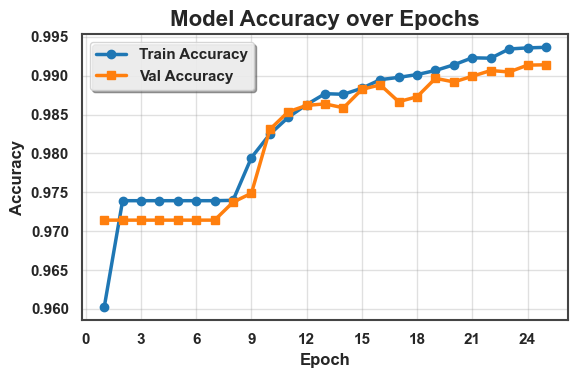

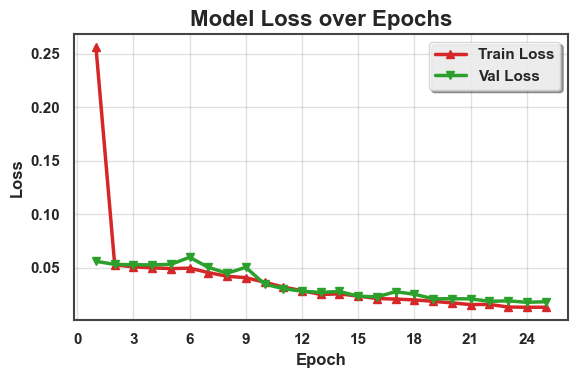

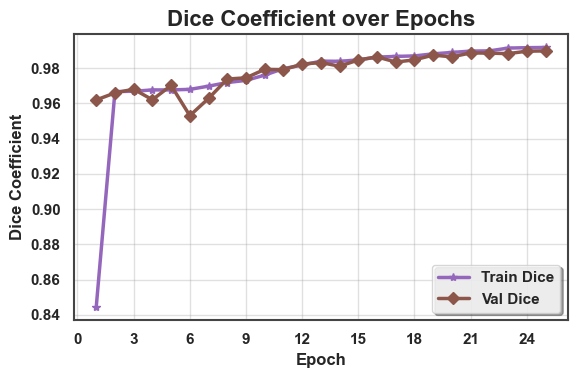

In [5]:
import matplotlib.ticker as ticker
import seaborn as sns
sns.set(style='whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.edgecolor': '#444',
    'axes.linewidth': 1.5,
    'grid.color': '#999999',
    'grid.alpha': 0.3,
    'lines.linewidth': 2.5,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': True,
})

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
dice = history.history['dice_coefficient']
val_dice = history.history['val_dice_coefficient']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, acc, label='Train Accuracy', color='#1f77b4', marker='o')
plt.plot(epochs, val_acc, label='Val Accuracy', color='#ff7f0e', marker='s')
plt.title('Model Accuracy over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, loss, label='Train Loss', color='#d62728', marker='^')
plt.plot(epochs, val_loss, label='Val Loss', color='#2ca02c', marker='v')
plt.title('Model Loss over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, dice, label='Train Dice', color='#9467bd', marker='*')
plt.plot(epochs, val_dice, label='Val Dice', color='#8c564b', marker='D')
plt.title('Dice Coefficient over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [27]:
metrics, y_pred = evaluate_model(model, X_test, y_test)
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
y_true_classes = np.argmax(y_test, axis=-1).flatten()
y_pred_classes = np.argmax(y_pred, axis=-1).flatten()

accuracy = np.mean(y_true_classes == y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='marco', zero_division=0)
recall = recall_score(y_true_classes, y_pred_classes, average='marco', zero_division=0)
f1 = f1_score(y_true_classes, y_pred_classes, average='marco', zero_division=0)
iou_metric = MeanIoU(num_classes=3)
iou_metric.update_state(y_true_classes, y_pred_classes)
mean_iou = iou_metric.result().numpy()

def dice_coef_np(y_true, y_pred, smooth=1):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

y_val_bin = np.argmax(y_val, axis=-1)
y_pred_bin = np.argmax(y_pred, axis=-1)
dice = dice_coef_np(y_val_bin == 1, y_pred_bin == 1)

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
per_class_acc = conf_matrix.diagonal() / conf_matrix.sum(axis=1)

print(f"Accuracy:{accuracy:.4f}")
print(f"Precision:{precision:.4f}")
print(f"Recall:{recall:.4f}")
print(f"F1 Score:{f1:.4f}")
print(f"Mean IoU:{mean_iou:.4f}")
print(f"Dice Coefficient:{dice:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
Accuracy:0.9914
Precision:0.9906
Recall:0.9914
F1 Score:0.9907
Mean IoU:0.9602
Dice Coefficient: 0.9898


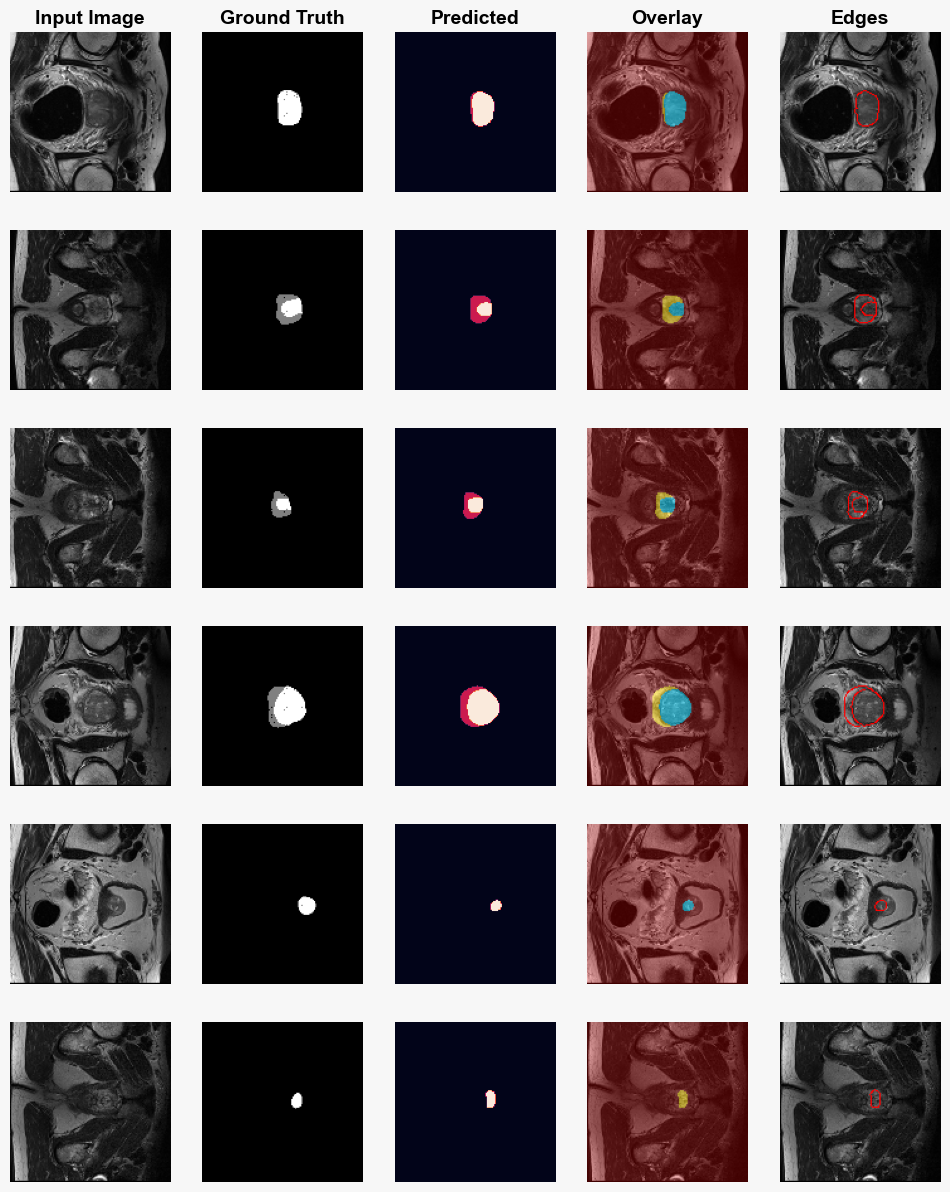

In [29]:
def show_predictions_range(start=6, end=12):
    num_samples = end - start
    fig, axes = plt.subplots(num_samples, 5, figsize=(12, num_samples * 2.5), facecolor='#f7f7f7')
    titles = ['Input Image', 'Ground Truth', 'Predicted', 'Overlay', 'Edges']

    for idx, i in enumerate(range(start, end)):
        input_img = X_test[i].squeeze()
        gt_mask = np.argmax(y_test[i], axis=-1)
        pred_mask = np.argmax(y_pred[i], axis=-1)
        input_norm = cv2.normalize(input_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        input_rgb = cv2.cvtColor(input_norm, cv2.COLOR_GRAY2BGR)
        color_pred = cv2.applyColorMap((pred_mask * 85).astype(np.uint8), cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(input_rgb, 0.7, color_pred, 0.5, 0)
        edges = cv2.Canny((pred_mask * 85).astype(np.uint8), 30, 100)
        edge_overlay = input_rgb.copy()
        edge_overlay[edges > 0] = [255, 0, 0] 
        axes[idx, 0].imshow(input_img, cmap='gray')
        axes[idx, 1].imshow(gt_mask, cmap='gray')
        axes[idx, 2].imshow(pred_mask)
        axes[idx, 3].imshow(overlay)
        axes[idx, 4].imshow(edge_overlay)

        for j in range(5):
            axes[idx, j].axis('off')
            if idx == 0:
                axes[0, j].set_title(titles[j], fontsize=14, fontweight='bold', color='black')

    plt.show()
show_predictions_range(start=6, end=12)

In [ ]:
import SimpleITK as sitk
from skimage.transform import resize
base_path = r"PROMISE12"
extract_path = os.path.join(base_path, "ChallengeData")

test_ratio = 0.3
TARGET_SIZE = (128, 128)  
def load_mhd(filepath):
    return sitk.GetArrayFromImage(sitk.ReadImage(filepath))
    
def resize_slice(slice_2d, target_size=(128, 128)):
    if slice_2d.ndim == 3 and slice_2d.shape[-1] == 1:
        resized = resize(slice_2d[:, :, 0], target_size, mode='reflect', preserve_range=True)
        resized_3ch = np.stack([resized, resized, resized], axis=-1)
        return resized_3ch.astype(np.float32)
    elif slice_2d.ndim == 2:
        resized = resize(slice_2d, target_size, mode='reflect', preserve_range=True)
        resized = (resized > 0.5).astype(np.float32)
        resized_3ch = np.stack([resized, resized, resized], axis=-1)
        return resized_3ch.astype(np.float32)

def load_2d_slices_resized_3ch():
    case_ids = []
    for f in os.listdir(extract_path):
        if f.startswith("Case") and f.endswith(".mhd") and "_segmentation" not in f:
            case_ids.append(f.replace(".mhd", ""))
    train_ids, test_ids = train_test_split(case_ids, test_size=test_ratio, random_state=42)
    
    X_train, y_train = [], []
    X_test, y_test = [], []
    
    for idx, case_id in enumerate(case_ids):
        img = load_mhd(os.path.join(extract_path, f"{case_id}.mhd"))
        seg = load_mhd(os.path.join(extract_path, f"{case_id}_segmentation.mhd"))
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        slices = []
        seg_slices = []
        for z in range(img.shape[0]):
            img_slice = img[z, :, :]  
            seg_slice = seg[z, :, :] 
            img_slice_resized = resize_slice(img_slice, TARGET_SIZE)
            seg_slice_resized = resize_slice(seg_slice, TARGET_SIZE)
            
            slices.append(img_slice_resized)
            seg_slices.append(seg_slice_resized)

        if case_id in train_ids:
            X_train.extend(slices)
            y_train.extend(seg_slices)
        else:
            X_test.extend(slices)
            y_test.extend(seg_slices)

    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train, dtype=np.float32)
    X_test = np.array(X_test, dtype=np.float32)
    y_test = np.array(y_test, dtype=np.float32)
    
    return X_train, y_train, X_test, y_test, train_ids, test_ids

X_train, y_train, X_test, y_test, train_ids, test_ids = load_2d_slices_resized_3ch()

In [29]:
metrics, y_pred = evaluate_model(model, X_test, y_test)
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
y_true_classes = np.argmax(y_test, axis=-1).flatten()
y_pred_classes = np.argmax(y_pred, axis=-1).flatten()

accuracy = np.mean(y_true_classes == y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='marco', zero_division=0)
recall = recall_score(y_true_classes, y_pred_classes, average='marco', zero_division=0)
f1 = f1_score(y_true_classes, y_pred_classes, average='marco', zero_division=0)
iou_metric = MeanIoU(num_classes=3)
iou_metric.update_state(y_true_classes, y_pred_classes)
mean_iou = iou_metric.result().numpy()

def dice_coef_np(y_true, y_pred, smooth=1):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

y_val_bin = np.argmax(y_val, axis=-1)
y_pred_bin = np.argmax(y_pred, axis=-1)
dice = dice_coef_np(y_val_bin == 1, y_pred_bin == 1)

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
per_class_acc = conf_matrix.diagonal() / conf_matrix.sum(axis=1)

print(f"Accuracy:{accuracy:.4f}")
print(f"Precision:{precision:.4f}")
print(f"Recall:{recall:.4f}")
print(f"F1 Score:{f1:.4f}")
print(f"Mean IoU:{mean_iou:.4f}")
print(f"Dice Coefficient:{dice:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
Accuracy:0.9932
Precision:0.8922
Recall:0.9053
F1 Score:0.8987
Mean IoU:0.8148
Dice Coefficient:0.8976


In [20]:
y_pred = model.predict(X_test)
def show_predictions_range(start=6, end=12):
    num_samples = end - start
    fig, axes = plt.subplots(
        num_samples,
        5,
        figsize=(12, num_samples * 2.5),
        facecolor='#f7f7f7'
    )
    titles = ['Input Image',
              'Ground Truth',
              'Predicted',
              'Overlay',
              'Edges']
    for idx, i in enumerate(range(start, end)):
        input_img = X_val[i].squeeze()
        gt_mask = y_val[i].squeeze()
        pred_prob = y_pred[i].squeeze()
        pred_mask = (pred_prob > 0.5).astype(np.uint8)
        input_norm = cv2.normalize(
            input_img,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        input_rgb = cv2.cvtColor(
            input_norm,
            cv2.COLOR_GRAY2BGR
        )
        color_pred = cv2.applyColorMap(
            pred_mask * 255,
            cv2.COLORMAP_JET
        )
        overlay = cv2.addWeighted(
            input_rgb,
            0.7,
            color_pred,
            0.5,
            0
        )

        edges = cv2.Canny(
            pred_mask * 255,
            30,
            100
        )
        edge_overlay = input_rgb.copy()
        edge_overlay[edges > 0] = [255, 0, 0]   # Red boundary
        axes[idx, 0].imshow(input_img, cmap='gray')
        axes[idx, 1].imshow(gt_mask, cmap='gray')
        axes[idx, 2].imshow(pred_mask, cmap='gray')
        axes[idx, 3].imshow(overlay)
        axes[idx, 4].imshow(edge_overlay)

        for j in range(5):
            axes[idx, j].axis('off')

            if idx == 0:
                axes[idx, j].set_title(
                    titles[j],
                    fontsize=13,
                    fontweight='bold'
                )
    plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 646ms/step


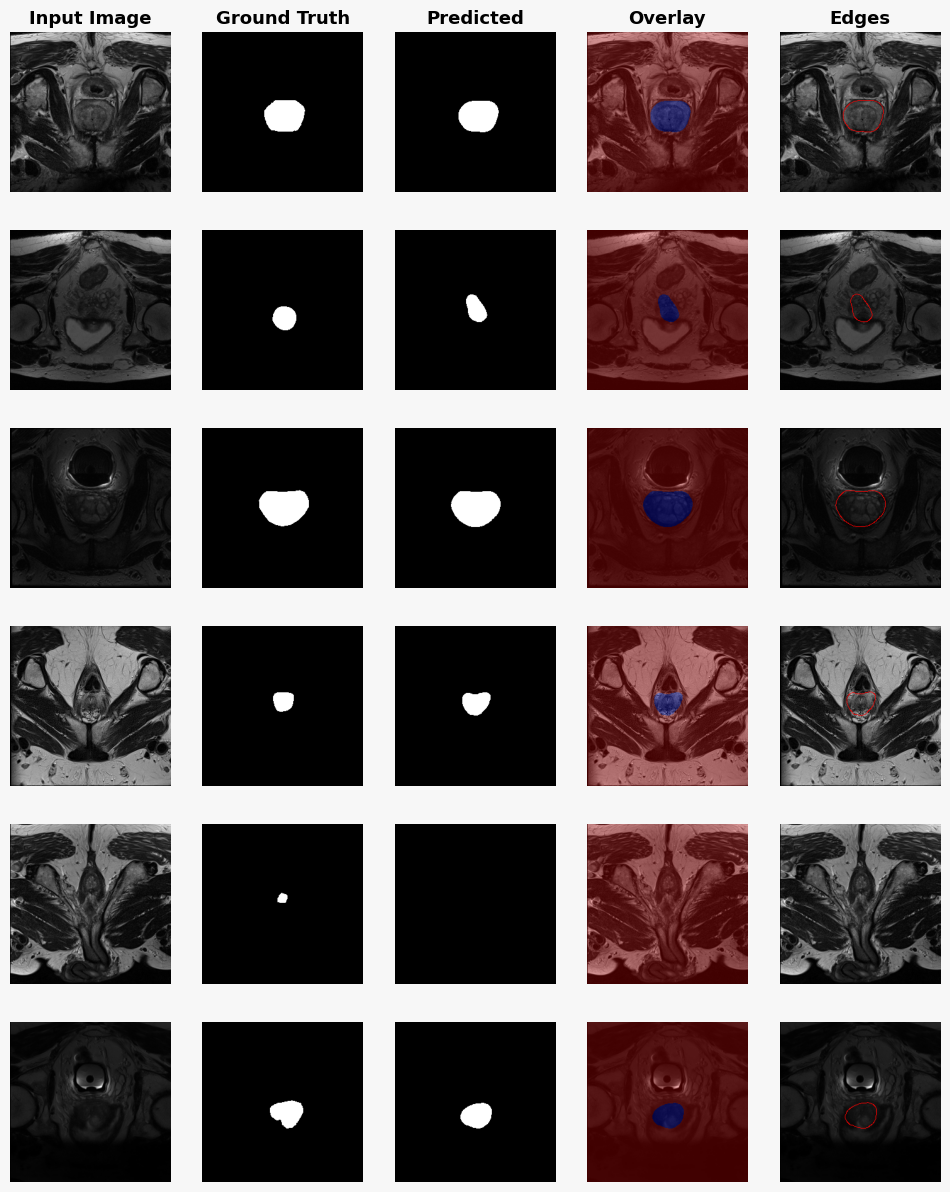

In [21]:
show_predictions_range(start=6, end=12)